# Проект по эконометрике

**Тема:** Гедонистическая ценовая функция — цена урока тенниса (Москва, Profi.ru). Тип 1.

**Конечная цель:** модель Хекмана (отбор в подвыборку тренеров с указанной ценой).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [2]:
df = pd.read_csv('data_processed/all_data_llm_tennis_moskow.csv')
df = df.rename(columns={'index': 'rang_id'})
df

,has_secondary_sport_education,has_higher_sport_education,sport_master,sport_master_kandidate,is_champion,work_experience,master_id,category,details,master_id.1,...,contract,cur_score,profi_ru_start,photos_count,achivements,experience,education,additional_info,about_coach,coach5_cols
0,True,False,False,False,False,4.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/AbelkhairovaSV/,...,NaN,50.493489,29,10,NaN,На сервисе с декабря 2023 г. (2 года)\nФотогра...,"РУС ГЦОЛИФК, реабилитация, ЛФКс 2023 г. (3 года)",NaN,Если ты всегда мечтал научиться играть в больш...,; На сервисе с декабря 2023 г. (2 года)\nФотог...
1,True,False,False,False,False,19.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/AbramovMB/,...,NaN,50.433670,2,0,NaN,На сервисе с марта 2026 г,NaN,NaN,NaN,; На сервисе с марта 2026 г; ; ;
2,False,True,True,False,True,8.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/AbyasovaAN/,...,NaN,50.350443,31,0,NaN,На сервисе с октября 2023 г. (2 года),NaN,NaN,"Стаж: 6 лет\nМастер спорта, многократный побед...",; На сервисе с октября 2023 г. (2 года); ; ; С...
3,True,False,False,False,False,2.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/AfanasyevBA4/,...,NaN,50.330329,15,8,NaN,"Компания СУЭК-КУЗБАСС МФСЦ""ГОРНЯК""2023–2025 гг...",АНО ДПО НАДПО программа дополнительного профес...,"Обучаю с ""0"". За полгода работы,ученики участв...",Тренер по большому теннису. Провожу индивидуал...,"; Компания СУЭК-КУЗБАСС МФСЦ""ГОРНЯК""2023–2025 ..."
4,True,False,True,False,False,3.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/AgureyevaKM2/,...,NaN,50.512069,8,0,Мастер спорта по теннису2022 г.\nДокументы и с...,На сервисе с сентября 2025 г,NaN,NaN,Здравствуйте! Меня зовут Ксения! Я мастер спор...,Мастер спорта по теннису2022 г.\nДокументы и с...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,True,False,False,True,False,5.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/ZhirkovaVA10/,...,NaN,50.094330,2,2,NaN,На сервисе с марта 2026 г\nФотографии2,NaN,NaN,"Всем привет! Меня зовут Вероника, я тренер по ...",; На сервисе с марта 2026 г\nФотографии2; ; ; ...
408,True,False,False,False,False,13.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/ZhuchkovaVS3/,...,NaN,50.019230,9,0,NaN,На сервисе с августа 2025 г,NaN,NaN,Тренер по теннису & Спарринг-партнер | Все уро...,; На сервисе с августа 2025 г; ; ; Тренер по т...
409,True,False,True,False,True,9.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/ZhukovMA78/,...,NaN,50.461117,1,3,NaN,На сервисе с апреля 2026 г\nФотографии3,NaN,NaN,Профессиональный теннисист (ATP 449).\nМастер ...,; На сервисе с апреля 2026 г\nФотографии3; ; ;...
410,True,True,True,False,True,4.0,https://profi.ru/profile/BazylevPN/,NaN,NaN,https://profi.ru/profile/ZykovaDS2/,...,NaN,50.479362,33,2,Мастер спорта по теннису2022 г.\nФотографии2\n...,На сервисе с августа 2023 г. (2 года),NaN,NaN,"Здравствуйте, меня зовут Дарья!\nС 3х лет проф...",Мастер спорта по теннису2022 г.\nФотографии2\n...


In [3]:
months = {'января': 1, 'февраля': 2, 'марта': 3, 'апреля': 4, 'мая': 5, 'июня': 6,
          'июля': 7, 'августа': 8, 'сентября': 9, 'октября': 10, 'ноября': 11, 'декабря': 12}

def profiru_start_transformer(value):
    month_count = None
    if pd.notna(value):
        list_val = value.split()
        month = list_val[3]
        year  = int(list_val[4])
        month_count = 12 * (2026 - year) + (5 - months[month])
    return month_count

df['is_highly_praised'] = df['is_highly_praised'].apply(lambda x: 1 if x == True else 0)
df['is_certified']      = df['is_certified'].apply(lambda x: 1 if x == True else 0)
df['docs_verified']     = df['docs_verified'].apply(lambda x: 1 if x == True else 0)
df['is_male']           = df['gender'].apply(lambda x: 1 if x == 'MALE' else 0)

df.drop(columns=['gender', 'contract', 'insurance', 'guarantee',
                 'assembledInfoListing', 'is_certified', 'master_id',
                 'category', 'details', 'discount'], inplace=True)

df.rename(columns={
    'profi_ru_start'  : 'months_on_profi_ru',
    'price_socket'    : 'price',
    'is_highly_praised': 'is_recomended',
    'master_id.1'     : 'master_id',
}, inplace=True)

df['cur_score'] = df['cur_score'].fillna(0)
df['rating']    = df['rating'].apply(lambda x: str(x).replace(',', '.')).astype('float')
df['has_price'] = df['price'].notna().astype('int')

df['has_secondary_sport_education'] = df['has_secondary_sport_education'].apply(lambda x: 1 if x == 'True' else 0)
df['has_higher_sport_education']    = df['has_higher_sport_education'].apply(lambda x: 1 if x == 'True' else 0)
df['sport_master']          = df['sport_master'].apply(lambda x: 1 if x == 'True' else 0)
df['sport_master_kandidate']= df['sport_master_kandidate'].apply(lambda x: 1 if x == 'True' else 0)
df['is_champion']           = df['is_champion'].apply(lambda x: 1 if x == 'True' else 0)

df['work_experience'] = df['work_experience'].fillna(df['months_on_profi_ru'] / 12)

# Иерархия: МС > КМС; высшее спорт. > среднее спорт.
df.loc[df['sport_master'] == 1, 'sport_master_kandidate'] = 0
df.loc[df['has_higher_sport_education'] == 1, 'has_secondary_sport_education'] = 0

df.drop(columns=['achivements', 'experience', 'education',
                 'additional_info', 'about_coach', 'coach5_cols'], inplace=True)

# rating = 0 → NaN (нет отзывов)
df['rating'] = df['rating'].replace(0.0, np.nan)

n_total  = len(df)
n_priced = int(df['has_price'].sum())
print(f'Всего тренеров   : {n_total}')
print(f'С указанной ценой: {n_priced} ({n_priced/n_total*100:.1f}%)')
print(f'Без цены         : {n_total - n_priced} ({(n_total-n_priced)/n_total*100:.1f}%)')
print()
df.dtypes

Всего тренеров   : 412
С указанной ценой: 319 (77.4%)
Без цены         : 93 (22.6%)



has_secondary_sport_education      int64
has_higher_sport_education         int64
sport_master                       int64
sport_master_kandidate             int64
is_champion                        int64
work_experience                  float64
master_id                         object
rang_id                          float64
docs_verified                      int64
rating                           float64
reviews_count                      int64
is_recomended                      int64
price                            float64
cur_score                        float64
months_on_profi_ru                 int64
photos_count                       int64
is_male                            int64
has_price                          int64
dtype: object

**Переменные датасета**

| Переменная | Описание |
|---|---|
| `price` | Цена урока (₽/час) — зависимая переменная |
| `has_price` | 1 = тренер указал цену в прайсе |
| `work_experience` | Лет опыта работы тренером |
| `rating` | Рейтинг по отзывам (0–5); 0 → нет отзывов |
| `reviews_count` | Число отзывов |
| `months_on_profi_ru` | Сколько месяцев тренер на платформе |
| `rang_id` | Место в поисковой выдаче (меньше = выше) |
| `cur_score` | Скоринг платформы |
| `photos_count` | Число фотографий в профиле |
| `docs_verified` | 1 = документы подтверждены Profi.ru |
| `is_recomended` | 1 = рекомендован платформой («Очень хвалят») |
| `is_male` | 1 = мужчина |
| `has_secondary_sport_education` | 1 = среднее спортивное образование (высшая указанная ступень) |
| `has_higher_sport_education` | 1 = высшее спортивное образование |
| `sport_master` | 1 = звание «Мастер спорта» (высшее указанное звание) |
| `sport_master_kandidate` | 1 = звание «КМС» (высшее указанное звание) |
| `is_champion` | 1 = чемпион (регион/страна/международный) |
| `master_id` | URL профиля (не используется в модели) |

## EDA — Исследовательский анализ данных

### 1. Анализ пропусков

In [13]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df  = (
    pd.DataFrame({'Кол-во пропусков': missing, 'Доля (%)': missing_pct})
    .query('`Кол-во пропусков` > 0')
    .sort_values('Доля (%)', ascending=False)
)
if missing_df.empty:
    print('Пропуски только в целевой переменной price.')
else:
    display(missing_df)

both = ((df['price'].isna()) & (df['has_price'] == 0)).sum()

,Кол-во пропусков,Доля (%)
rating,139,33.7
price,93,22.6


### 2. Дескриптивная статистика

In [5]:
num_cols = [
    'work_experience', 'rating', 'reviews_count', 'price',
    'cur_score', 'rang_id', 'photos_count', 'months_on_profi_ru'
]

def describe_subset(sub, title):
    desc = sub[num_cols].describe(percentiles=[.25, .5, .75]).T
    desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    desc.columns = ['N', 'Среднее', 'Ст.откл.', 'Min', 'Q1', 'Медиана', 'Q3', 'Max']
    for col in desc.columns[1:]:
        desc[col] = desc[col].round(2)
    print(f"\n{'='*65}")
    print(f'  {title}')
    print('='*65)
    display(desc)

describe_subset(df, f'Полная выборка (n={len(df)})')
describe_subset(df[df['has_price']==1],
                f'Подвыборка: тренеры с указанной ценой (n={int(df["has_price"].sum())})')


  Полная выборка (n=412)


,N,Среднее,Ст.откл.,Min,Q1,Медиана,Q3,Max
work_experience,412.0,10.62,8.10,0.0,4.00,9.00,15.00,46.00
rating,273.0,4.94,0.20,3.0,5.00,5.00,5.00,5.00
reviews_count,412.0,10.06,18.88,0.0,0.00,3.00,11.00,161.00
price,319.0,3176.58,1303.69,850.0,2500.00,3000.00,4000.00,10000.00
cur_score,412.0,50.33,2.99,0.0,50.37,50.47,50.54,70.38
rang_id,412.0,97.00,41.63,0.0,75.00,101.50,121.00,196.00
photos_count,412.0,5.86,24.31,0.0,0.00,3.00,7.00,472.00
months_on_profi_ru,412.0,49.91,46.57,0.0,11.00,34.00,74.00,190.00



  Подвыборка: тренеры с указанной ценой (n=319)


,N,Среднее,Ст.откл.,Min,Q1,Медиана,Q3,Max
work_experience,319.0,11.39,8.07,0.17,5.00,10.00,16.00,46.00
rating,226.0,4.94,0.20,3.00,5.00,5.00,5.00,5.00
reviews_count,319.0,11.48,20.48,0.00,0.00,4.00,12.00,161.00
price,319.0,3176.58,1303.69,850.00,2500.00,3000.00,4000.00,10000.00
cur_score,319.0,50.32,3.39,0.00,50.38,50.48,50.54,70.38
rang_id,319.0,92.33,40.30,0.00,73.00,98.00,117.00,196.00
photos_count,319.0,5.04,6.44,0.00,0.00,4.00,8.00,48.00
months_on_profi_ru,319.0,56.80,48.16,1.00,17.00,47.00,82.00,190.00


### 3. Зависимая переменная: price

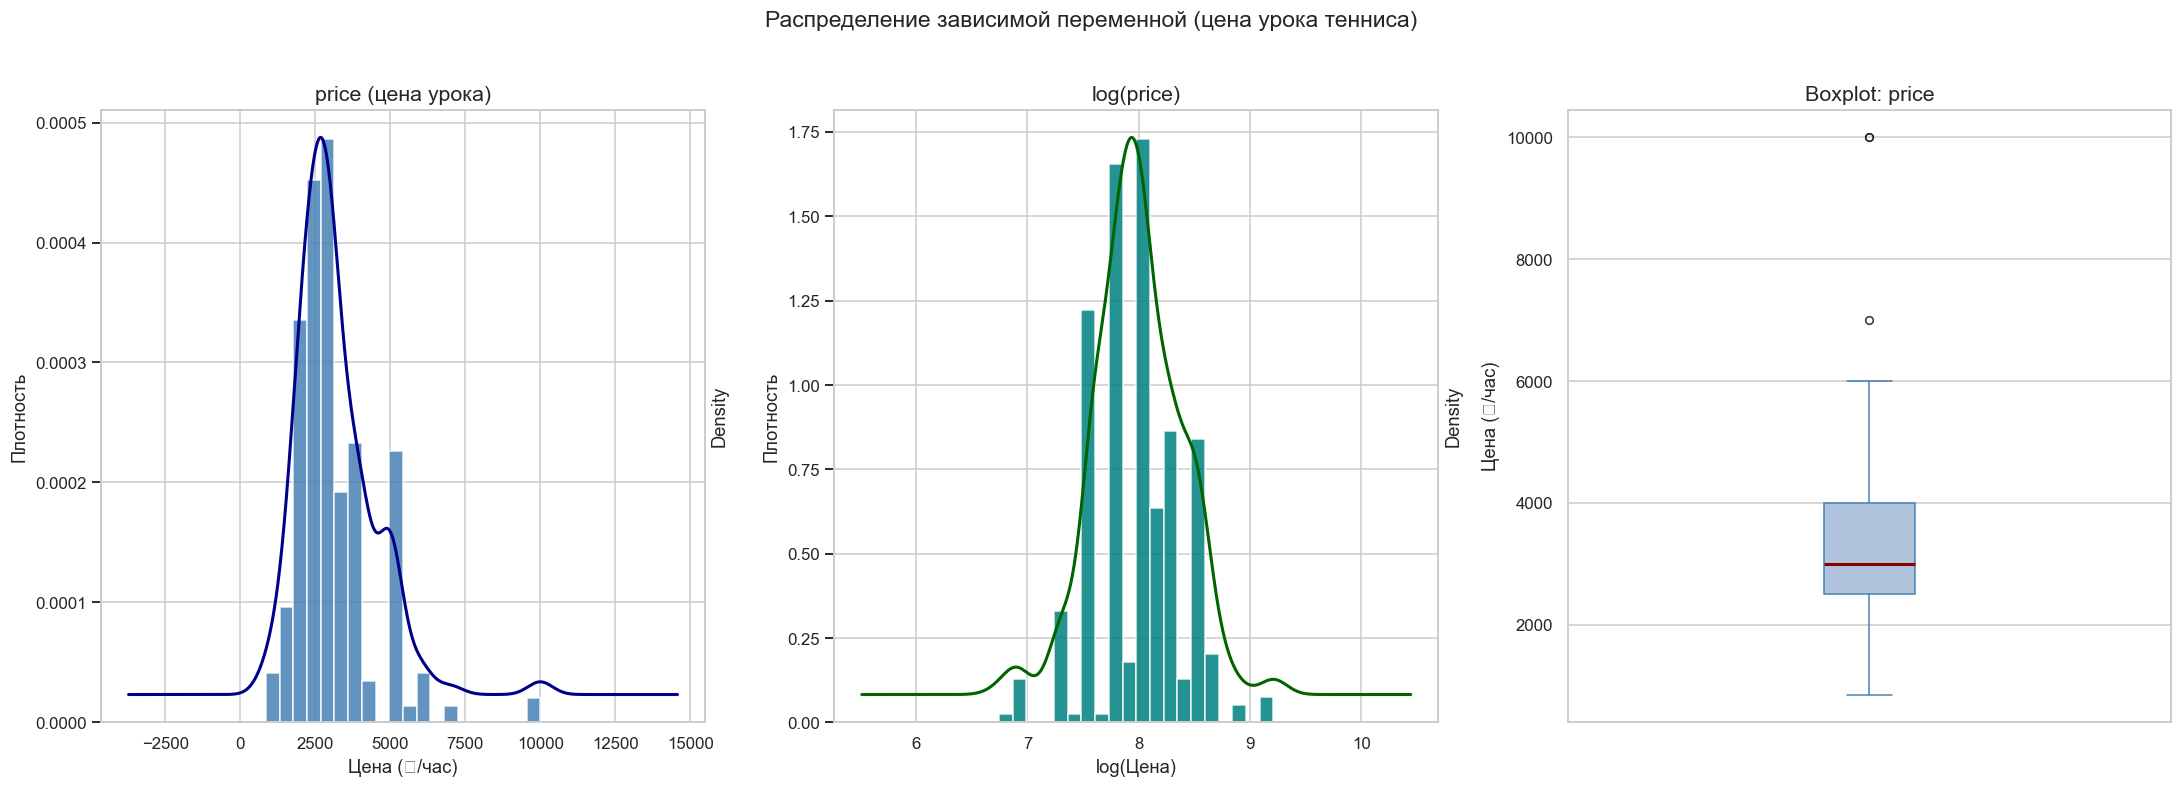

Медиана    : 3000 ₽/час
Среднее    : 3177 ₽/час
Асимметрия : 1.753  (уровень)
Асимметрия : 0.003  (log)

Вывод: log-трансформация рекомендуется


In [6]:
prices     = df['price'].dropna()
log_prices = np.log(prices)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Гистограмма + KDE
axes[0].hist(prices, bins=20, color='steelblue', edgecolor='white', alpha=0.85, density=True)
ax0b = axes[0].twinx()
prices.plot.kde(ax=ax0b, color='darkblue', linewidth=2)
ax0b.set_yticks([])
axes[0].set_title('price (цена урока)', fontsize=14)
axes[0].set_xlabel('Цена (₽/час)', fontsize=12)
axes[0].set_ylabel('Плотность', fontsize=12)
axes[0].tick_params(labelsize=11)

# log(price)
axes[1].hist(log_prices, bins=20, color='teal', edgecolor='white', alpha=0.85, density=True)
ax1b = axes[1].twinx()
log_prices.plot.kde(ax=ax1b, color='darkgreen', linewidth=2)
ax1b.set_yticks([])
axes[1].set_title('log(price)', fontsize=14)
axes[1].set_xlabel('log(Цена)', fontsize=12)
axes[1].set_ylabel('Плотность', fontsize=12)
axes[1].tick_params(labelsize=11)

# Boxplot
axes[2].boxplot(
    prices, vert=True, patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
    medianprops=dict(color='darkred', linewidth=2),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
    flierprops=dict(marker='o', color='steelblue', alpha=0.5, markersize=5)
)
axes[2].set_title('Boxplot: price', fontsize=14)
axes[2].set_ylabel('Цена (₽/час)', fontsize=12)
axes[2].set_xticks([])
axes[2].tick_params(labelsize=11)

plt.suptitle('Распределение зависимой переменной (цена урока тенниса)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f'Медиана    : {prices.median():.0f} ₽/час')
print(f'Среднее    : {prices.mean():.0f} ₽/час')
print(f'Асимметрия : {prices.skew():.3f}  (уровень)')
print(f'Асимметрия : {log_prices.skew():.3f}  (log)')
print(f"\nВывод: {'log-трансформация рекомендуется' if abs(log_prices.skew()) < abs(prices.skew()) else 'log не улучшает симметрию'}")

### 4. Распределения непрерывных регрессоров

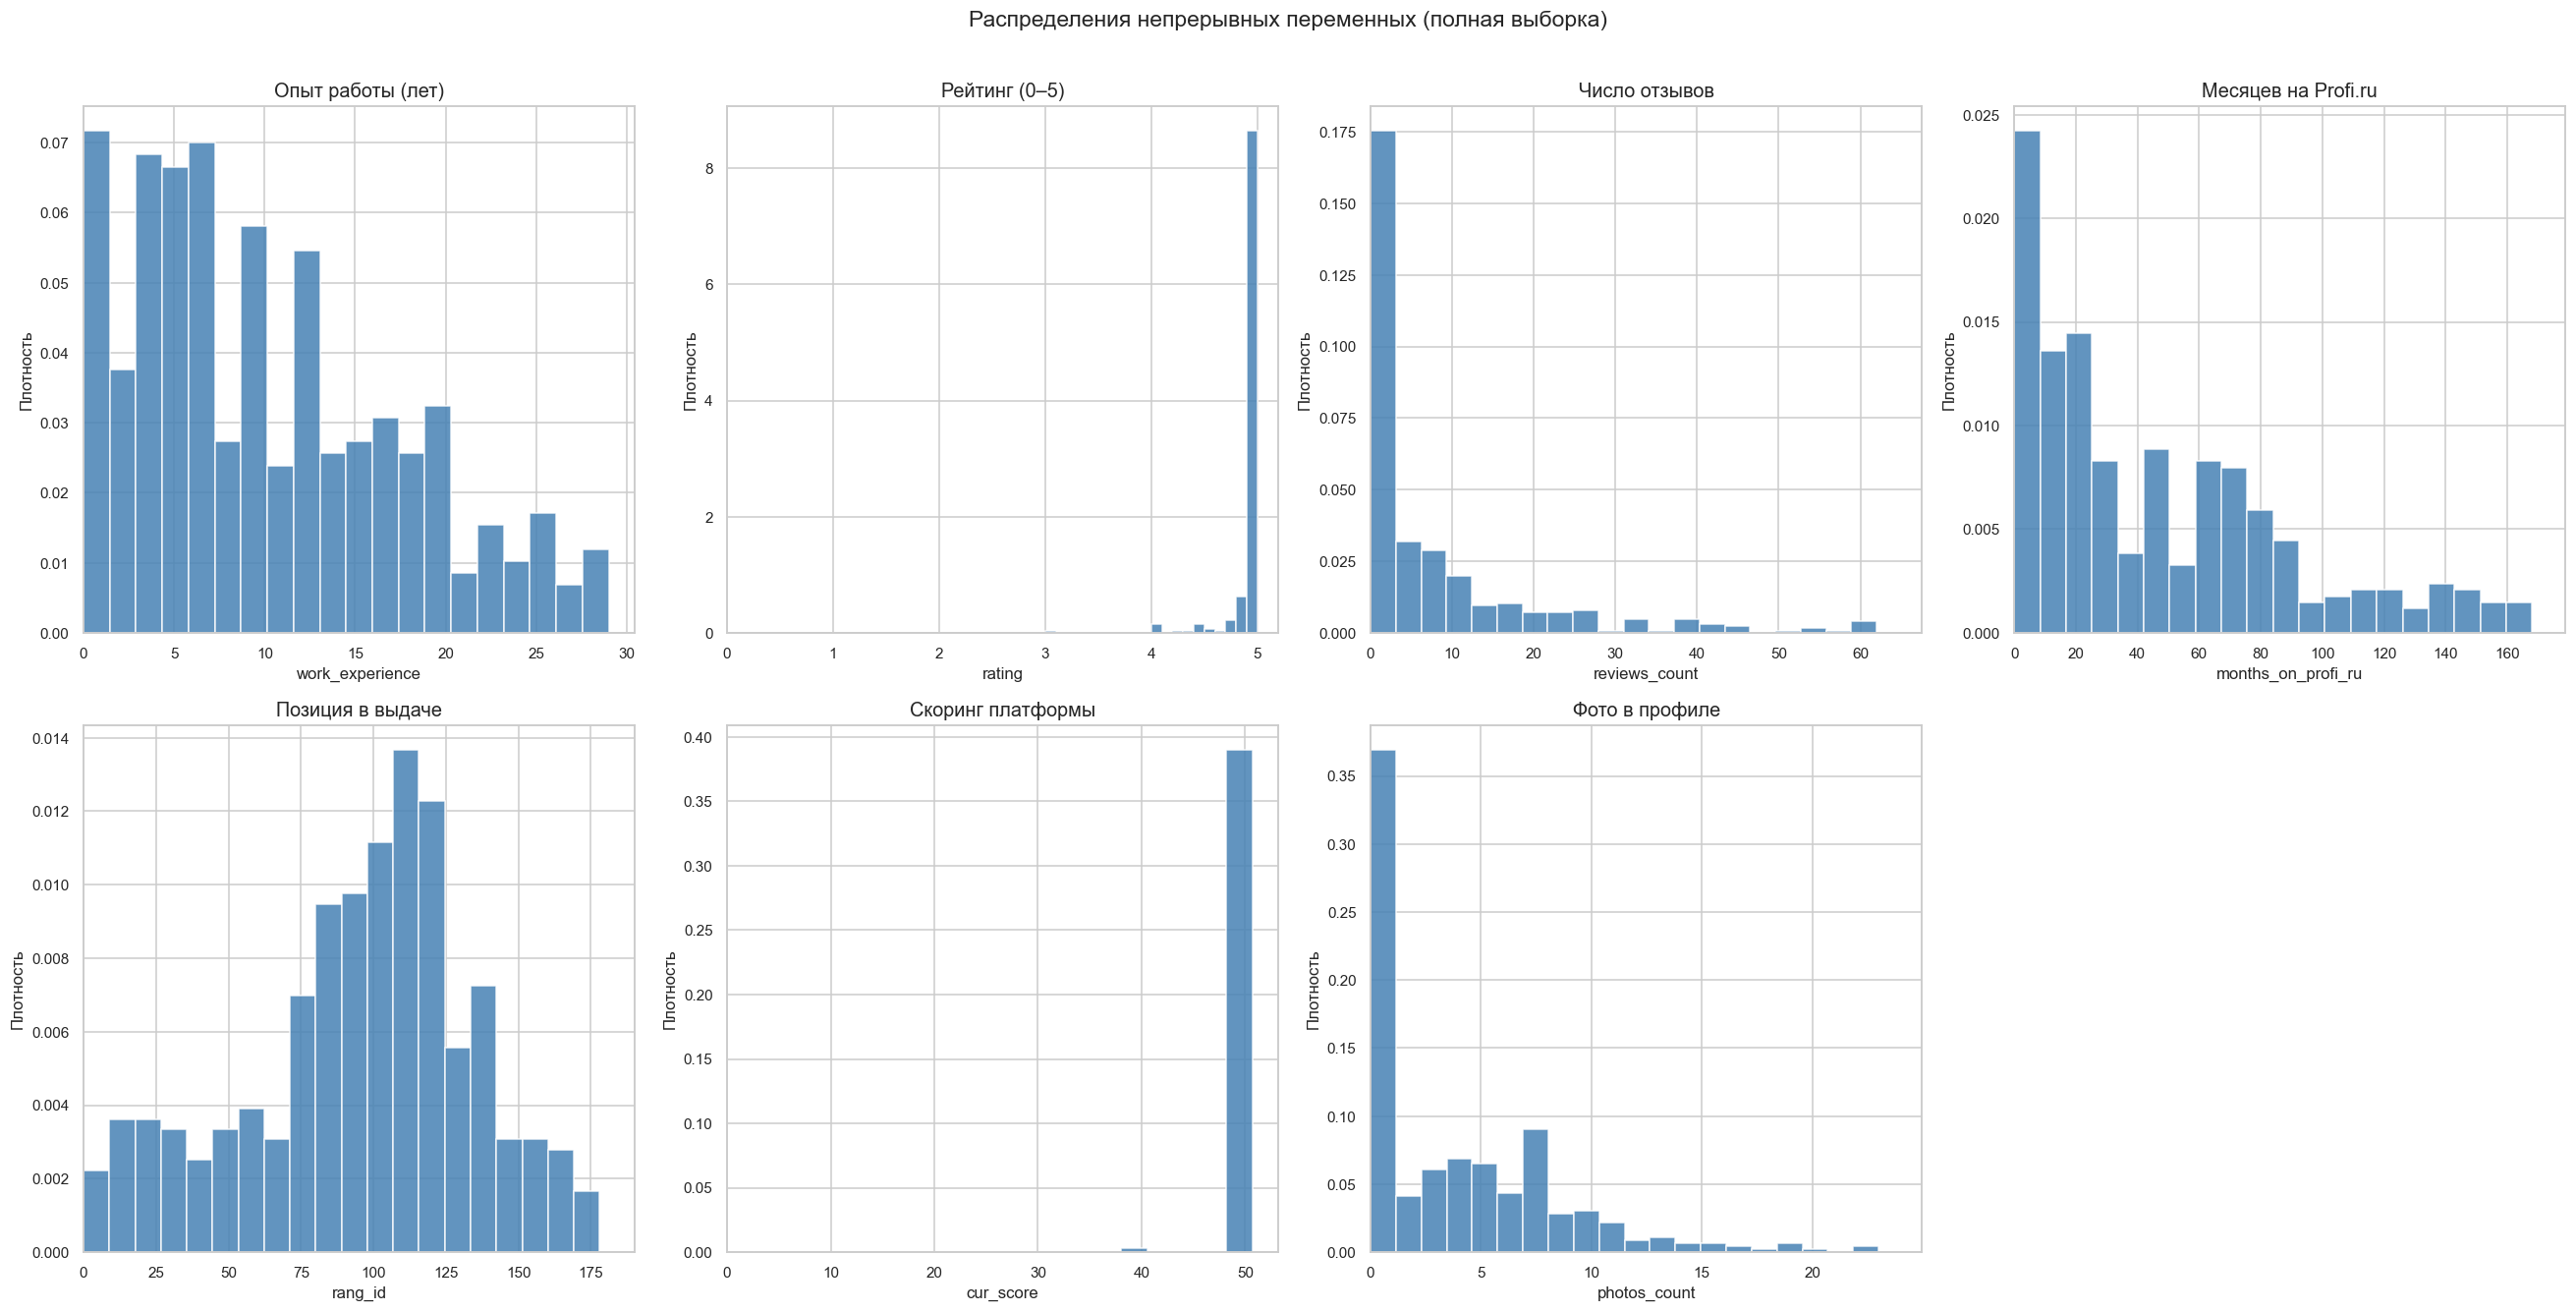

Примечание: rating=NaN означает отсутствие рейтинга (нет отзывов).
Для остальных переменных ось X ограничена 98-м процентилем (редкие выбросы скрыты для читаемости).


In [7]:
cont_vars = {
    'work_experience'   : 'Опыт работы (лет)',
    'rating'            : 'Рейтинг (3–5)',
    'reviews_count'     : 'Число отзывов',
    'months_on_profi_ru': 'Месяцев на Profi.ru',
    'rang_id'           : 'Позиция в выдаче',
    'cur_score'         : 'Скоринг платформы',
    'photos_count'      : 'Фото в профиле',
}

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, (col, title) in enumerate(cont_vars.items()):
    data = df[col].dropna()
    ax   = axes[idx]
    if col == 'rating':
        ax.hist(data, bins=20, color='steelblue', edgecolor='white', alpha=0.85, density=True)
        ax.set_xlim(data.min() - 0.1, 5.2)
    else:
        q98 = data.quantile(0.98)
        ax.hist(data[data <= q98], bins=20, color='steelblue', edgecolor='white', alpha=0.85, density=True)
        ax.set_xlim(0, q98 * 1.05)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Плотность', fontsize=11)
    ax.tick_params(labelsize=10)

axes[-1].set_visible(False)
plt.suptitle('Распределения непрерывных переменных (полная выборка)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('Примечание: rating=NaN означает отсутствие рейтинга (нет отзывов).')
print('Для остальных переменных ось X ограничена 98-м процентилем (редкие выбросы скрыты для читаемости).')

### 5. Категориальные и бинарные переменные

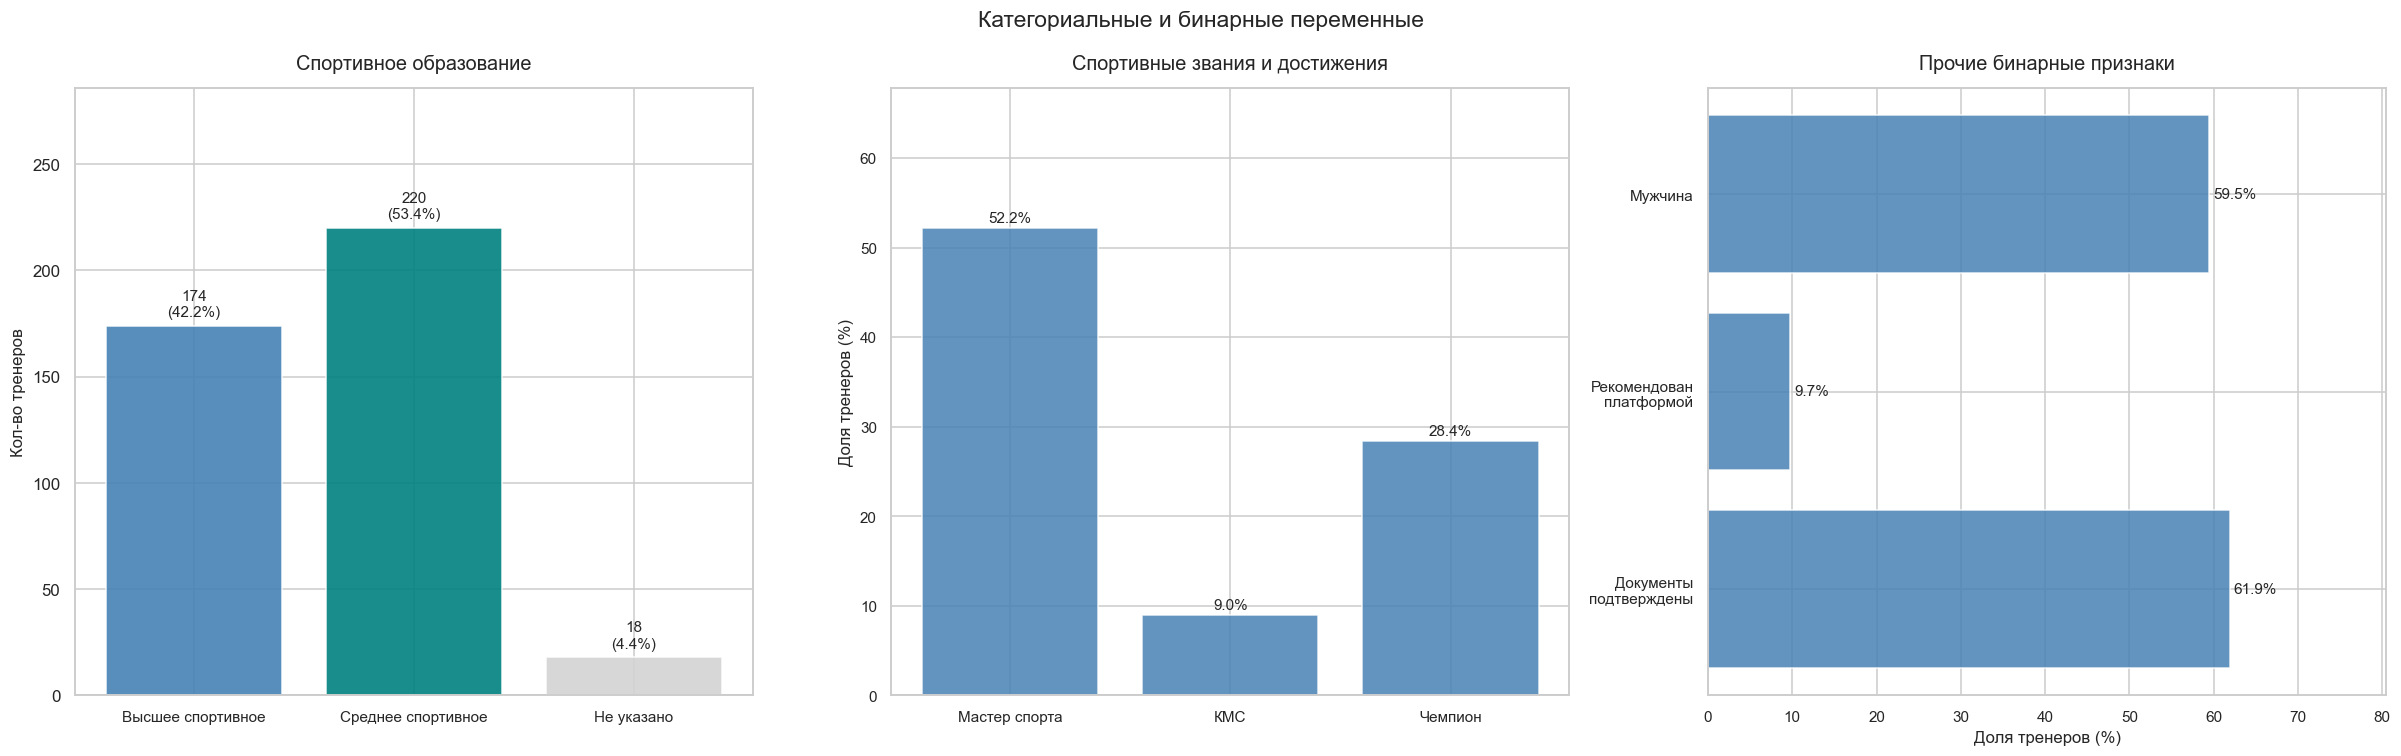

In [8]:
def edu_sport_category(row):
    if row['has_higher_sport_education'] == 1:
        return 'Высшее спортивное'
    elif row['has_secondary_sport_education'] == 1:
        return 'Среднее спортивное'
    else:
        return 'Не указано'

edu_counts = df.apply(edu_sport_category, axis=1).value_counts()\
              .reindex(['Высшее спортивное', 'Среднее спортивное', 'Не указано'])
edu_pcts   = edu_counts / len(df) * 100

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Образование
bars = axes[0].bar(edu_counts.index, edu_counts.values,
                   color=['steelblue', 'teal', 'lightgray'], edgecolor='white', alpha=0.9)
axes[0].set_title('Спортивное образование', fontsize=13, pad=12)
axes[0].set_ylabel('Кол-во тренеров', fontsize=11)
axes[0].tick_params(axis='x', labelsize=10)
axes[0].set_ylim(0, edu_counts.max() * 1.3)
for bar, pct in zip(bars, edu_pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{bar.get_height():.0f}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# Звания
rank_cols   = ['sport_master', 'sport_master_kandidate', 'is_champion']
rank_labels = ['Мастер спорта', 'КМС', 'Чемпион']
rank_shares = [df[c].mean() * 100 for c in rank_cols]
bars2 = axes[1].bar(rank_labels, rank_shares, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Спортивные звания и достижения', fontsize=13, pad=12)
axes[1].set_ylabel('Доля тренеров (%)', fontsize=11)
axes[1].set_ylim(0, max(rank_shares) * 1.3)
axes[1].tick_params(labelsize=10)
for bar, v in zip(bars2, rank_shares):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

# Прочие бинарные
other_bin    = ['docs_verified', 'is_recomended', 'is_male']
other_labels = ['Документы\nподтверждены', 'Рекомендован\nплатформой', 'Мужчина']
shares = [df[c].mean() * 100 for c in other_bin]
bars3 = axes[2].barh(other_labels, shares, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Доля тренеров (%)', fontsize=11)
axes[2].set_title('Прочие бинарные признаки', fontsize=13, pad=12)
axes[2].set_xlim(0, max(shares) * 1.3)
axes[2].tick_params(labelsize=10)
for bar, v in zip(bars3, shares):
    axes[2].text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)

plt.suptitle('Категориальные и бинарные переменные', fontsize=15)
plt.tight_layout()
plt.show()

### 6. Selection-анализ: тренеры с ценой vs без цены

In [9]:
mask     = df['has_price'] == 1
priced   = df[mask]
unpriced = df[~mask]

print(f'С ценой: {mask.sum()} | Без цены: {(~mask).sum()}\n')

compare_cols = [
    ('work_experience',    'Опыт (лет)'),
    ('rating',             'Рейтинг'),
    ('reviews_count',      'Число отзывов'),
    ('months_on_profi_ru', 'Месяцев на Profi.ru'),
    ('rang_id',            'Позиция в выдаче'),
    ('cur_score',          'Скоринг платформы'),
    ('photos_count',       'Фото'),
]

rows = []
for col, label in compare_cols:
    a = priced[col].dropna()
    b = unpriced[col].dropna()
    _, p = ttest_ind(a, b, equal_var=False)
    rows.append({
        'Признак'              : label,
        'Среднее (с ценой)'    : round(a.mean(), 2),
        'Среднее (без цены)'   : round(b.mean(), 2),
        'Разница'              : round(a.mean() - b.mean(), 2),
        'p-value'              : round(p, 4),
        'Значимо (p<0.05)'     : '✓' if p < 0.05 else '',
    })

display(pd.DataFrame(rows))

С ценой: 319 | Без цены: 93



,Признак,Среднее (с ценой),Среднее (без цены),Разница,p-value,Значимо (p<0.05)
0,Опыт (лет),11.39,7.97,3.43,0.0002,✓
1,Рейтинг,4.94,4.93,0.01,0.7280,
2,Число отзывов,11.48,5.18,6.30,0.0001,✓
3,Месяцев на Profi.ru,56.80,26.25,30.56,0.0000,✓
4,Позиция в выдаче,92.33,113.01,-20.68,0.0000,✓
5,Скоринг платформы,50.32,50.40,-0.08,0.6695,
6,Фото,5.04,8.67,-3.63,0.4860,


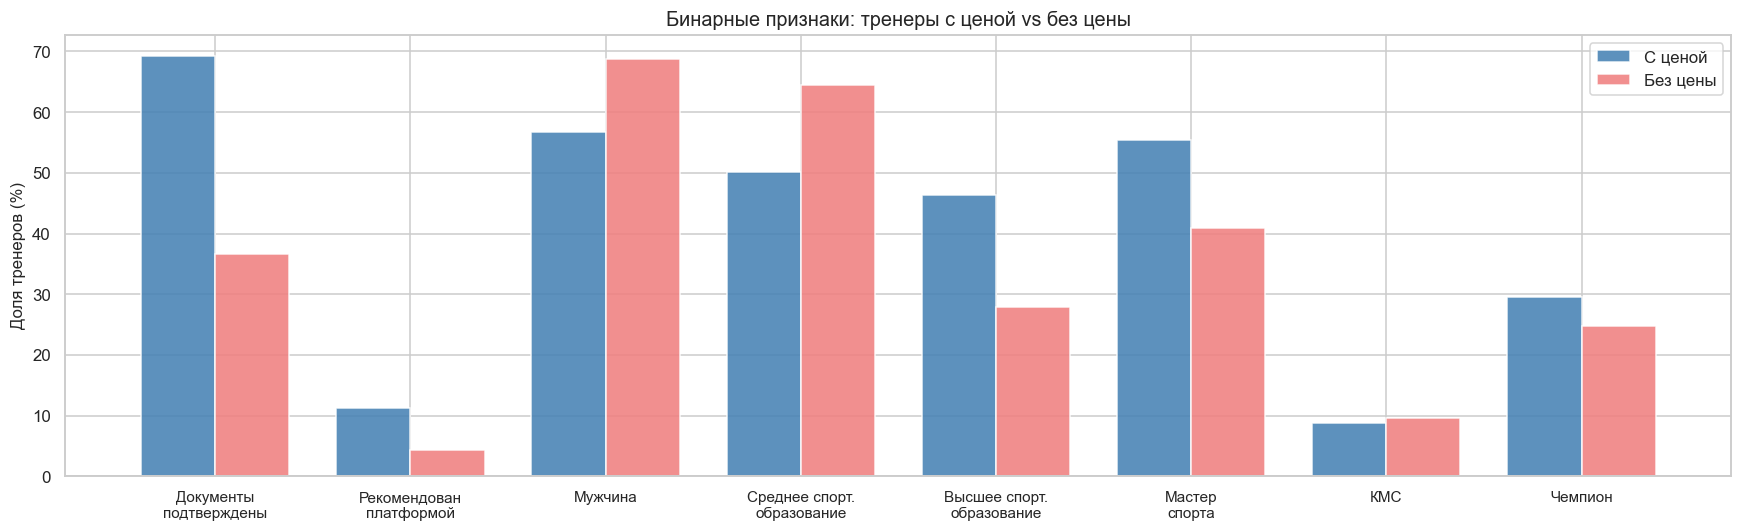

In [10]:
bin_sel_cols   = ['docs_verified', 'is_recomended', 'is_male',
                  'has_secondary_sport_education', 'has_higher_sport_education',
                  'sport_master', 'sport_master_kandidate', 'is_champion']
bin_sel_labels = ['Документы\nподтверждены', 'Рекомендован\nплатформой', 'Мужчина',
                  'Среднее спорт.\nобразование', 'Высшее спорт.\nобразование',
                  'Мастер\nспорта', 'КМС', 'Чемпион']

x = np.arange(len(bin_sel_cols))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w/2, [priced[c].mean()*100   for c in bin_sel_cols], w,
       label='С ценой',  color='steelblue',  alpha=0.88, edgecolor='white')
ax.bar(x + w/2, [unpriced[c].mean()*100 for c in bin_sel_cols], w,
       label='Без цены', color='lightcoral', alpha=0.88, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(bin_sel_labels, fontsize=10)
ax.set_ylabel('Доля тренеров (%)', fontsize=11)
ax.set_title('Бинарные признаки: тренеры с ценой vs без цены', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 7. Корреляционный анализ

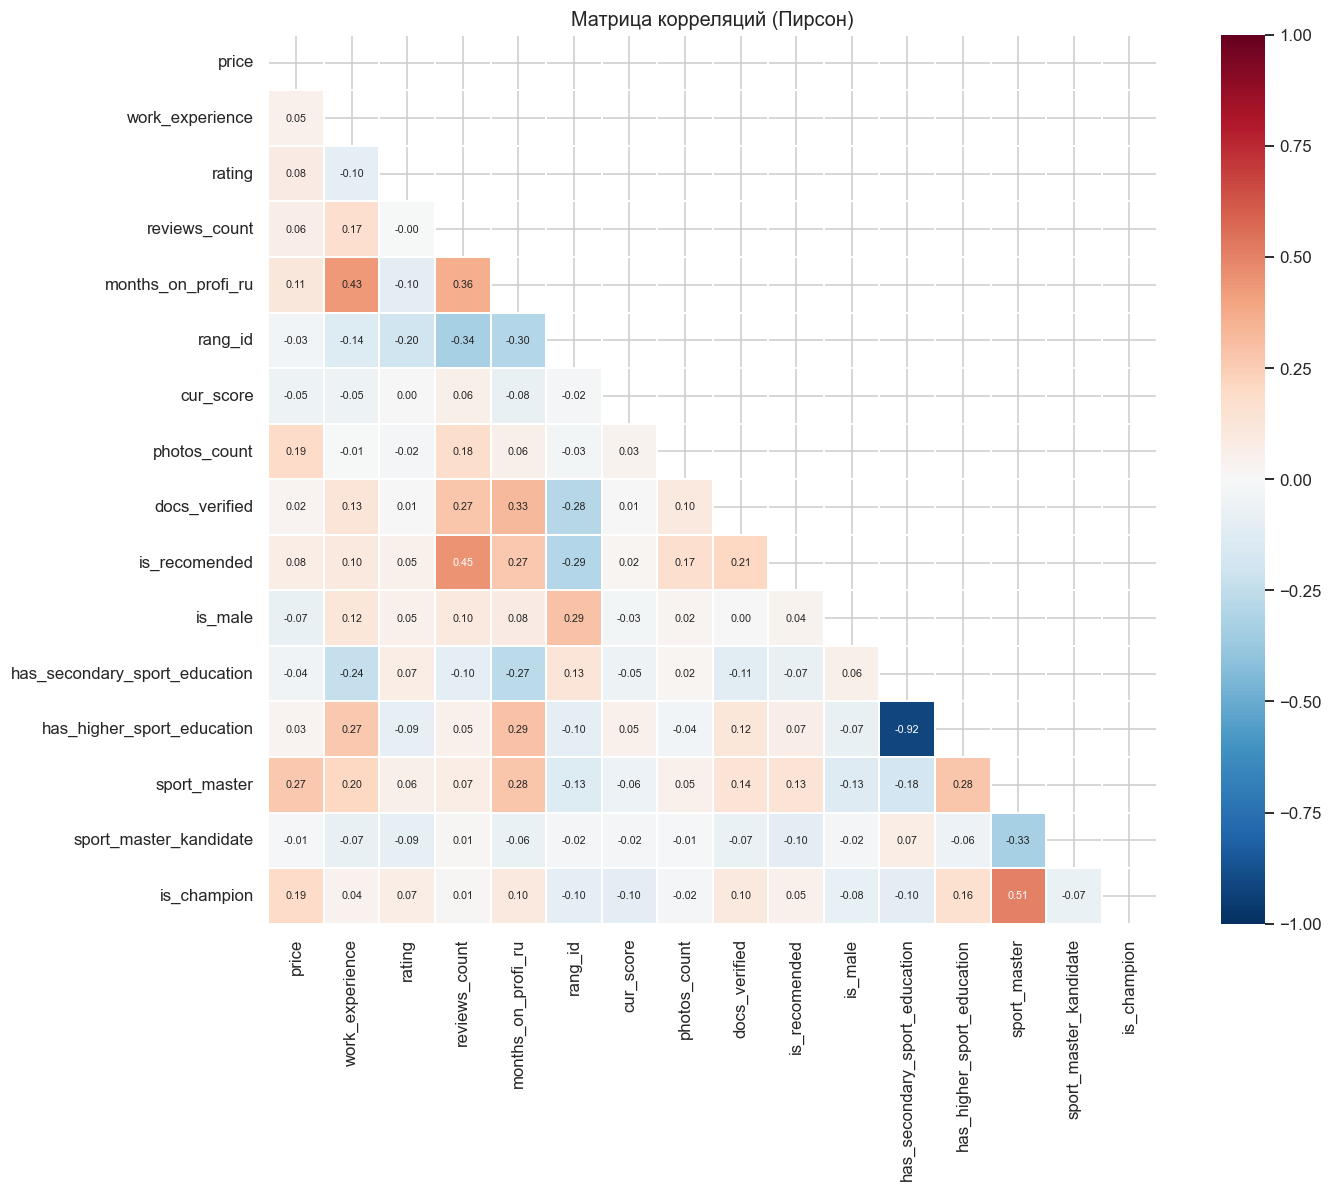

Корреляции с price (по убыванию |r|):
sport_master                     0.270620
is_champion                      0.192823
photos_count                     0.189552
months_on_profi_ru               0.111848
rating                           0.080750
is_recomended                    0.077963
is_male                         -0.073069
reviews_count                    0.064979
work_experience                  0.054272
cur_score                       -0.050343
has_secondary_sport_education   -0.043366
rang_id                         -0.033920
has_higher_sport_education       0.027747
docs_verified                    0.024040
sport_master_kandidate          -0.013995


In [11]:
corr_cols = [
    'price', 'work_experience', 'rating', 'reviews_count',
    'months_on_profi_ru', 'rang_id', 'cur_score', 'photos_count',
    'docs_verified', 'is_recomended', 'is_male',
    'has_secondary_sport_education', 'has_higher_sport_education',
    'sport_master', 'sport_master_kandidate', 'is_champion',
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask_upper, ax=ax,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, square=True
)
ax.set_title('Матрица корреляций (Пирсон)', fontsize=13)
plt.tight_layout()
plt.show()

price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print('Корреляции с price (по убыванию |r|):')
print(price_corr.to_string())

### 8. Scatter-графики: цена vs предикторы

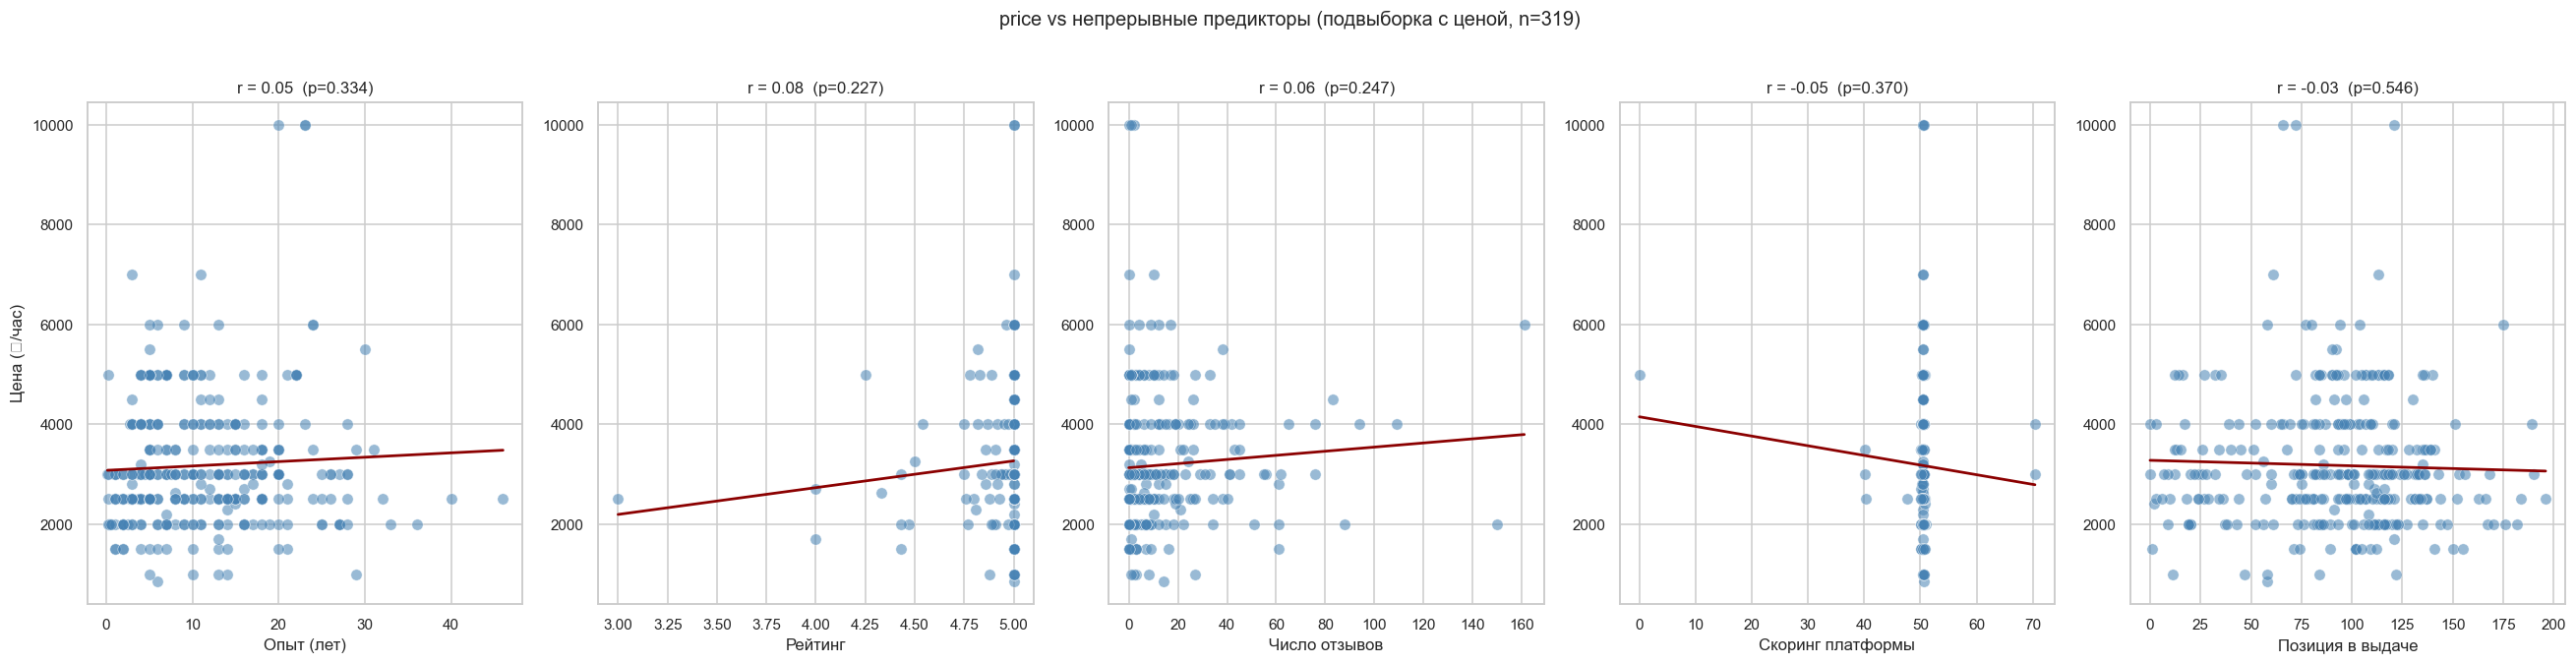

In [12]:
scatter_vars = [
    ('work_experience',    'Опыт (лет)'),
    ('rating',             'Рейтинг'),
    ('reviews_count',      'Число отзывов'),
    ('cur_score',          'Скоринг платформы'),
    ('rang_id',            'Позиция в выдаче'),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 6))

for i, (col, label) in enumerate(scatter_vars):
    sub    = df[df['price'].notna() & df[col].notna()]
    x_data = sub[col].values
    y_data = sub['price'].values

    axes[i].scatter(x_data, y_data, alpha=0.55, s=55,
                    color='steelblue', edgecolors='white', linewidths=0.4)

    slope, intercept, r_val, p_val, _ = stats.linregress(x_data, y_data)
    x_line = np.linspace(x_data.min(), x_data.max(), 80)
    axes[i].plot(x_line, slope * x_line + intercept, color='darkred', linewidth=1.8)

    axes[i].set_xlabel(label, fontsize=11)
    axes[i].set_ylabel('Цена (₽/час)' if i == 0 else '', fontsize=11)
    axes[i].set_title(f'r = {r_val:.2f}  (p={p_val:.3f})', fontsize=11)
    axes[i].tick_params(labelsize=10)

n_sub = int(df['price'].notna().sum())
plt.suptitle(f'price vs непрерывные предикторы (подвыборка с ценой, n={n_sub})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 9. Итоговые выводы EDA

**Данные и пропуски**
- Выборка: 412 тренеров по теннису (Москва, Profi.ru), у 319 (77.4%) указана цена урока
- Пропуск `price` означает, что тренер **не добавил стоимость урока в прайс**
- Пропущенных значений в предикторах нет

---

**Зависимая переменная**
- `price` (₽/час) имеет умеренную правостороннюю асимметрию → **log-трансформация рекомендуется**
- Несколько наблюдений с ценой 10 000 ₽ — возможно, элитные тренеры; не удаляются как ошибка

---

**Основание для модели Хекмана**
- Тренеры с ценой и без неё **систематически различаются** по ключевым признакам (t-test): у первых выше рейтинг, больше отзывов, лучше скоринг

---

**Кандидаты в exclusion restriction** *(влияют на решение указать цену, но не на её уровень)*

Найти строго валидный инструмент в этих данных сложно — большинство переменных потенциально влияют и на отбор, и на уровень цены.

- `is_recomended` — плашка «Очень хвалят» стимулирует активность профиля (и добавление прайса), однако высокая оценка клиентами может одновременно позволять тренеру брать более высокую цену. **Условно подходит**, но предположение спорно
- `rang_id` — позиция в выдаче отражает активность на платформе (→ больше шансов добавить прайс), но высокая позиция даёт видимость, что потенциально влияет на спрос и цену. **Слабый инструмент**

Ни один из кандидатов не является заведомо экзогенным. Ограничение исключения принимается как рабочая гипотеза и должно быть обосновано содержательно при финальном оформлении модели.

---

**Ожидаемые знаки коэффициентов (уравнение цены)**

Знаки согласуются как со здравым смыслом, так и с направлением наклона регрессионных прямых на scatter-графиках раздела 8.

| Признак | Ожидаемый знак | Обоснование |
|---|:---:|---|
| `work_experience` | **+** | Опытные тренеры берут дороже |
| `rating` | **+** | Высокий рейтинг → ценовая премия |
| `reviews_count` | **+** | Репутация снижает неопределённость → выше цена |
| `sport_master` | **+** | Звание МС → сигнал качества |
| `is_champion` | **+** | Титул чемпиона → дополнительная ценность |
| `has_higher_sport_education` | **+** | Профессиональная подготовка → выше ставка |
| `is_male` | **?** | Гендерный разрыв в оплате — неоднозначно |
| `cur_score` | **+** | Внутренний скоринг — знак уточняется по корреляции |

---

**Потенциальные проблемы**
- Мультиколлинеарность: `reviews_count` и `rating` вероятно скоррелированы; `sport_master` и `is_champion` — тоже. Проверить VIF
- Спортивные звания (`sport_master`, `sport_master_kandidate`, `is_champion`) могут образовывать иерархию и давать мультиколлинеарность
- Подвыборка с ценой (n=319) достаточно велика — можно использовать до 12–15 регрессоров